### COMPLEX CNN

In [1]:
# Import libraries
from pathlib import Path
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader

In [2]:
# Set the path to the project root directory
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").is_dir():
    raise FileNotFoundError("Project src/ folder not found")

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "checkpoints"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

METRICS_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "metrics"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
# Import project modules
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )

from src.data.dataset import (
    HAM10000Dataset,
    HAM10000_CLASSES,
    CLASS_TO_IDX,
    IDX_TO_CLASS,
)

from src.data.preprocessing import (
    get_eval_transform,
)

from src.data.augmentation import (
    get_train_transform,
)

from src.models.complex_cnn import (
    ComplexCNN,
)

In [4]:
# Reproducibility
import random
import numpy as np
import torch


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Random seed set to {SEED}")

Random seed set to 42


In [5]:
# Device
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cpu


In [6]:
# Load split data
train_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "train.csv"
)

val_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "val.csv"
)

test_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "test.csv"
)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

Train: 6981
Validation: 1532
Test: 1502


In [7]:
# Transforms
IMAGE_SIZE = 224

train_transform = (
    get_train_transform(
        image_size=IMAGE_SIZE
    )
)

eval_transform = (
    get_eval_transform(
        image_size=IMAGE_SIZE
    )
)

In [8]:
# Dataset
train_dataset = HAM10000Dataset(
    dataframe=train_df,
    project_root=PROJECT_ROOT,
    transform=train_transform,
)

val_dataset = HAM10000Dataset(
    dataframe=val_df,
    project_root=PROJECT_ROOT,
    transform=eval_transform,
)

test_dataset = HAM10000Dataset(
    dataframe=test_df,
    project_root=PROJECT_ROOT,
    transform=eval_transform,
)

In [9]:
# DataLoaders
BATCH_SIZE = 32

NUM_WORKERS = 0


generator = torch.Generator()

generator.manual_seed(
    SEED
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

In [10]:
# Match the checkpointed refined architecture exactly.
NUM_CLASSES = 7
model = ComplexCNN(num_classes=NUM_CLASSES, dropout=0.4, block_dropout=[0.0]*4, adaptive_pool_size=(4,4)).to(device)
print(model)


ComplexCNN(
  (features): Sequential(
    (0): CNNBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.0, inplace=False)
      )
    )
    (1): CNNBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1

In [11]:
# Check model output
images, labels = next(
    iter(train_loader)
)

images = images.to(
    device
)

with torch.no_grad():

    outputs = model(
        images
    )

print(
    "Input shape:",
    images.shape
)

print(
    "Output shape:",
    outputs.shape
)

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 7])


In [12]:
# Count the number of parameters in the model
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: "
    f"{total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)

Total parameters: 2,223,847
Trainable parameters: 2,223,847


In [13]:
# Import training modules
from src.training.losses import (
    compute_class_weights,
    get_weighted_cross_entropy_loss,
)

from src.training.train import (
    fit,
)

In [14]:
# Historical refined loss configuration (no fitting performed).
class_weights = compute_class_weights(train_df, HAM10000_CLASSES, device=device)
criterion = get_weighted_cross_entropy_loss(class_weights, label_smoothing=0.05, soften=True)
print(criterion)


CrossEntropyLoss()


In [15]:
# Read the previously saved training history only.
from pathlib import Path
CHECKPOINT_PATH = CHECKPOINT_DIR / "complex_cnn_best.pt"
if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(f"Missing existing checkpoint: {CHECKPOINT_PATH}")
HISTORY_PATH = METRICS_DIR / "complex_cnn_training_history.csv"
if not HISTORY_PATH.is_file():
    candidates = sorted(METRICS_DIR.glob("*complex_cnn*history*.csv"))
    HISTORY_PATH = candidates[0] if candidates else HISTORY_PATH
if HISTORY_PATH.is_file():
    history_df = pd.read_csv(HISTORY_PATH)
    print("Loaded history:", HISTORY_PATH)
else:
    history_df = pd.DataFrame(columns=["epoch","train_loss","val_loss","train_accuracy","val_accuracy"])
    print("Training history not found; plots will be skipped. Checkpoint remains usable.")
print("No training performed. Checkpoint preserved:", CHECKPOINT_PATH)


Loaded history: C:\Deep Learning\skin-lesion-classification\outputs\metrics\complex_cnn_training_history.csv
No training performed. Checkpoint preserved: C:\Deep Learning\skin-lesion-classification\outputs\checkpoints\complex_cnn_best.pt


In [16]:
history_df

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate
0,1,1.850451,0.609798,1.589699,0.642298,0.0010
1,2,1.739324,0.630569,1.478232,0.654047,0.0010
2,3,1.692994,0.638161,1.597798,0.593995,0.0010
3,4,1.676360,0.646899,1.441984,0.671018,0.0010
4,5,1.655304,0.659361,1.443516,0.676893,0.0010
5,6,1.638480,0.656066,1.438744,0.677546,0.0010
6,7,1.611523,0.660937,1.496465,0.633159,0.0010
7,8,1.611477,0.656639,1.429685,0.671018,0.0010
8,9,1.597886,0.664375,1.483380,0.667102,0.0010
9,10,1.594275,0.668242,1.420298,0.674282,0.0010


In [17]:
# Safely load existing checkpoint (including legacy NumPy-backed .pt files).
from src.checkpoint_io import load_model
model = load_model(model, CHECKPOINT_PATH, device)
model.eval()
print("Existing model weights loaded:", CHECKPOINT_PATH)


C:\Deep Learning\skin-lesion-classification\src\checkpoint_io.py:60: RuntimeWarning: Using legacy torch.load for a trusted local HAM10000 checkpoint. Untrusted .pt files can execute code when unpickled.
  obj = _trusted_legacy_load(path)


Existing model weights loaded: C:\Deep Learning\skin-lesion-classification\outputs\checkpoints\complex_cnn_best.pt


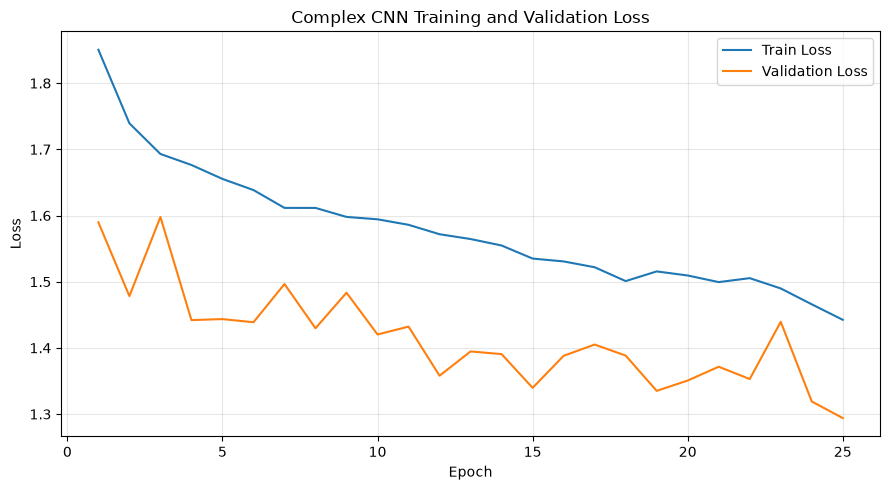

In [18]:
# Plot loss
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss",
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss",
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Complex CNN Training and Validation Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "complex_cnn_loss_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

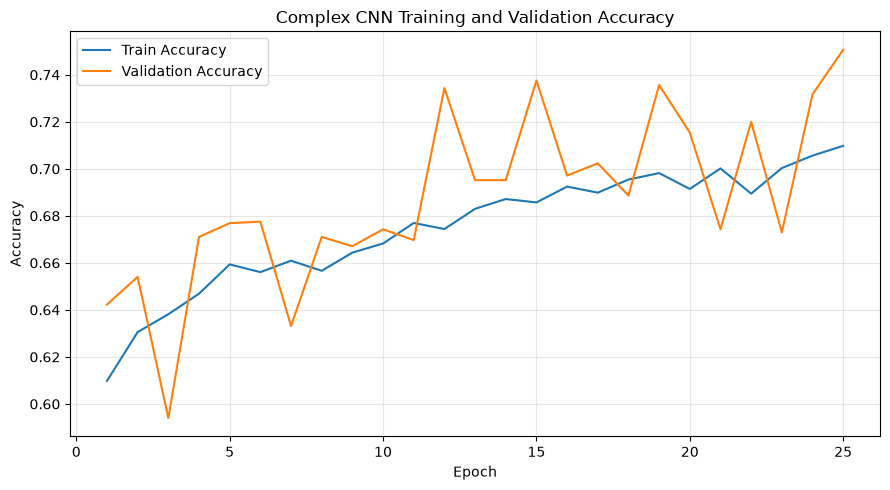

In [19]:
# Plot accuracy
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Train Accuracy",
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy",
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Complex CNN Training and Validation Accuracy"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "complex_cnn_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()